In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Device: GPU (CUDA)")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Device: CPU")

Device: CPU


In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [24]:
train_full_dataset= datasets.MNIST(root='./data',train=True,download=True,transform=transform)

In [25]:
test_dataset=datasets.MNIST(root='./data',train=False,download=True,transform=transform)

In [8]:
train_size=50000
val_size=10000

In [26]:
train_dataset, val_dataset = random_split(train_full_dataset, [train_size, val_size])

In [10]:
print("Dataset Information:" )
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))


Dataset Information:
Train dataset size: 50000
Validation dataset size: 10000
Test dataset size: 10000


In [27]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

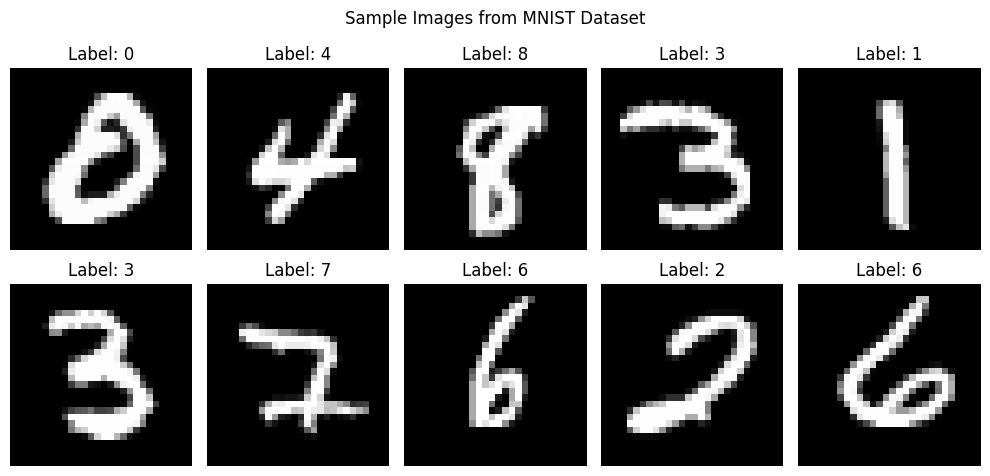

In [12]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.suptitle("Sample Images from MNIST Dataset")
plt.tight_layout()
plt.show()

In [13]:
input_size= 784
hidden_size_1= 128
hidden_size_2= 64
output_size= 10


In [28]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(   
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):

        return self.network(x)

In [15]:
class MLP_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),           
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


In [16]:
class MLP_BatchNorm(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),          
            nn.Linear(784, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    correct = 0
    total = 0
    running_loss = 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy

In [31]:
def evaluate(model, loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total
    return epoch_loss, epoch_accuracy


In [32]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history={"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    print("Training started...")
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer
                )
        val_loss, val_acc = evaluate(
                    model,
                    val_loader,
                    criterion
                )
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(
                    f"Epoch [{epoch + 1:02d}/{epochs}] | "
                    f"Train Loss: {train_loss:.4f} | "
                    f"Train Acc: {train_acc:.2f}% | "
                    f"Val Loss: {val_loss:.4f} | "
                    f"Val Acc: {val_acc:.2f}%"
                )
        
    print("-" * 70)
        
    return history
        

    

In [33]:
epochs = 10

In [34]:
print("\n")
print("=" * 70)
print("EXPERIMENT A: BASELINE - NO REGULARIZATION")
print("=" * 70)

model_baseline = MLP().to(device)

optimizer_baseline = optim.Adam(
    model_baseline.parameters(),
    lr=0.001
)
history_baseline = train_model(
    model_baseline,
    train_loader,
    val_loader,
    criterion,
    optimizer_baseline,
    epochs
)



EXPERIMENT A: BASELINE - NO REGULARIZATION
Training started...
Epoch [01/10] | Train Loss: 0.3563 | Train Acc: 89.76% | Val Loss: 0.1938 | Val Acc: 94.16%
Epoch [02/10] | Train Loss: 0.1504 | Train Acc: 95.53% | Val Loss: 0.1339 | Val Acc: 95.97%
Epoch [03/10] | Train Loss: 0.1023 | Train Acc: 96.84% | Val Loss: 0.1095 | Val Acc: 96.96%
Epoch [04/10] | Train Loss: 0.0759 | Train Acc: 97.68% | Val Loss: 0.0990 | Val Acc: 97.02%
Epoch [05/10] | Train Loss: 0.0598 | Train Acc: 98.14% | Val Loss: 0.0878 | Val Acc: 97.39%
Epoch [06/10] | Train Loss: 0.0447 | Train Acc: 98.54% | Val Loss: 0.1006 | Val Acc: 97.06%
Epoch [07/10] | Train Loss: 0.0385 | Train Acc: 98.75% | Val Loss: 0.0938 | Val Acc: 97.48%
Epoch [08/10] | Train Loss: 0.0334 | Train Acc: 98.93% | Val Loss: 0.0954 | Val Acc: 97.63%
Epoch [09/10] | Train Loss: 0.0246 | Train Acc: 99.22% | Val Loss: 0.0951 | Val Acc: 97.61%
Epoch [10/10] | Train Loss: 0.0222 | Train Acc: 99.29% | Val Loss: 0.0987 | Val Acc: 97.62%
---------------

In [35]:
print("\n")
print("=" * 70)
print("EXPERIMENT B: L2 REGULARIZATION")
print("=" * 70)

model_l2 = MLP().to(device)

optimizer_l2 = optim.Adam(
    model_l2.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


history_l2 = train_model(
    model_l2,
    train_loader,
    val_loader,
    criterion,
    optimizer_l2,
    epochs
)



EXPERIMENT B: L2 REGULARIZATION
Training started...
Epoch [01/10] | Train Loss: 0.3470 | Train Acc: 89.82% | Val Loss: 0.1922 | Val Acc: 94.10%
Epoch [02/10] | Train Loss: 0.1518 | Train Acc: 95.42% | Val Loss: 0.1322 | Val Acc: 95.93%
Epoch [03/10] | Train Loss: 0.1024 | Train Acc: 96.89% | Val Loss: 0.1110 | Val Acc: 96.69%
Epoch [04/10] | Train Loss: 0.0758 | Train Acc: 97.71% | Val Loss: 0.1026 | Val Acc: 96.89%
Epoch [05/10] | Train Loss: 0.0611 | Train Acc: 98.09% | Val Loss: 0.0961 | Val Acc: 96.98%
Epoch [06/10] | Train Loss: 0.0500 | Train Acc: 98.45% | Val Loss: 0.0918 | Val Acc: 97.29%
Epoch [07/10] | Train Loss: 0.0414 | Train Acc: 98.63% | Val Loss: 0.0925 | Val Acc: 97.36%
Epoch [08/10] | Train Loss: 0.0359 | Train Acc: 98.86% | Val Loss: 0.0962 | Val Acc: 97.33%
Epoch [09/10] | Train Loss: 0.0282 | Train Acc: 99.06% | Val Loss: 0.0979 | Val Acc: 97.34%
Epoch [10/10] | Train Loss: 0.0253 | Train Acc: 99.17% | Val Loss: 0.1030 | Val Acc: 97.10%
--------------------------

In [36]:
print("\n")
print("=" * 70)
print("EXPERIMENT C: DROPOUT (p = 0.3)")
print("=" * 70)

model_dropout = MLP_Dropout().to(device)


optimizer_dropout = optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)


history_dropout = train_model(
    model_dropout,
    train_loader,
    val_loader,
    criterion,
    optimizer_dropout,
    epochs
)




EXPERIMENT C: DROPOUT (p = 0.3)
Training started...
Epoch [01/10] | Train Loss: 0.4948 | Train Acc: 84.89% | Val Loss: 0.2025 | Val Acc: 93.90%
Epoch [02/10] | Train Loss: 0.2411 | Train Acc: 92.92% | Val Loss: 0.1520 | Val Acc: 95.48%
Epoch [03/10] | Train Loss: 0.1886 | Train Acc: 94.38% | Val Loss: 0.1294 | Val Acc: 96.02%
Epoch [04/10] | Train Loss: 0.1656 | Train Acc: 95.18% | Val Loss: 0.1140 | Val Acc: 96.45%
Epoch [05/10] | Train Loss: 0.1460 | Train Acc: 95.62% | Val Loss: 0.1067 | Val Acc: 96.93%
Epoch [06/10] | Train Loss: 0.1341 | Train Acc: 95.87% | Val Loss: 0.1060 | Val Acc: 96.99%
Epoch [07/10] | Train Loss: 0.1192 | Train Acc: 96.36% | Val Loss: 0.0944 | Val Acc: 97.26%
Epoch [08/10] | Train Loss: 0.1156 | Train Acc: 96.53% | Val Loss: 0.1036 | Val Acc: 97.08%
Epoch [09/10] | Train Loss: 0.1080 | Train Acc: 96.68% | Val Loss: 0.0958 | Val Acc: 97.43%
Epoch [10/10] | Train Loss: 0.1049 | Train Acc: 96.83% | Val Loss: 0.0952 | Val Acc: 97.38%
--------------------------

In [37]:
print("\n")
print("=" * 70)
print("EXPERIMENT D: BATCH NORMALIZATION")
print("=" * 70)
model_batchnorm = MLP_BatchNorm().to(device)
optimizer_batchnorm = optim.Adam(
    model_batchnorm.parameters(),
    lr=0.001
)

history_batchnorm = train_model(
    model_batchnorm,
    train_loader,
    val_loader,
    criterion,
    optimizer_batchnorm,
    epochs
)



EXPERIMENT D: BATCH NORMALIZATION
Training started...
Epoch [01/10] | Train Loss: 0.3310 | Train Acc: 92.64% | Val Loss: 0.1223 | Val Acc: 96.60%
Epoch [02/10] | Train Loss: 0.0971 | Train Acc: 97.24% | Val Loss: 0.0922 | Val Acc: 97.21%
Epoch [03/10] | Train Loss: 0.0656 | Train Acc: 98.04% | Val Loss: 0.0803 | Val Acc: 97.55%
Epoch [04/10] | Train Loss: 0.0472 | Train Acc: 98.58% | Val Loss: 0.0771 | Val Acc: 97.60%
Epoch [05/10] | Train Loss: 0.0372 | Train Acc: 98.87% | Val Loss: 0.0762 | Val Acc: 97.76%
Epoch [06/10] | Train Loss: 0.0304 | Train Acc: 99.06% | Val Loss: 0.0737 | Val Acc: 97.83%
Epoch [07/10] | Train Loss: 0.0241 | Train Acc: 99.25% | Val Loss: 0.0779 | Val Acc: 97.67%
Epoch [08/10] | Train Loss: 0.0211 | Train Acc: 99.34% | Val Loss: 0.0747 | Val Acc: 97.73%
Epoch [09/10] | Train Loss: 0.0182 | Train Acc: 99.46% | Val Loss: 0.0778 | Val Acc: 97.80%
Epoch [10/10] | Train Loss: 0.0170 | Train Acc: 99.44% | Val Loss: 0.0798 | Val Acc: 97.83%
------------------------

In [38]:
results = {

    "Baseline": history_baseline,

    "L2": history_l2,

    "Dropout": history_dropout,

    "BatchNorm": history_batchnorm
}

In [39]:
print("\n")
print("=" * 70)
print("FINAL ACCURACY COMPARISON")
print("=" * 70)

print(
    f"{'Configuration':<15}"
    f"{'Train Accuracy':<20}"
    f"{'Validation Accuracy':<20}"
)

print("-" * 55)

for name, history in results.items():

    final_train_accuracy = history["train_acc"][-1]

    final_validation_accuracy = history["val_acc"][-1]

    print(
        f"{name:<15}"
        f"{final_train_accuracy:<20.2f}"
        f"{final_validation_accuracy:<20.2f}"
    )




FINAL ACCURACY COMPARISON
Configuration  Train Accuracy      Validation Accuracy 
-------------------------------------------------------
Baseline       99.29               97.62               
L2             99.17               97.10               
Dropout        96.83               97.38               
BatchNorm      99.44               97.83               


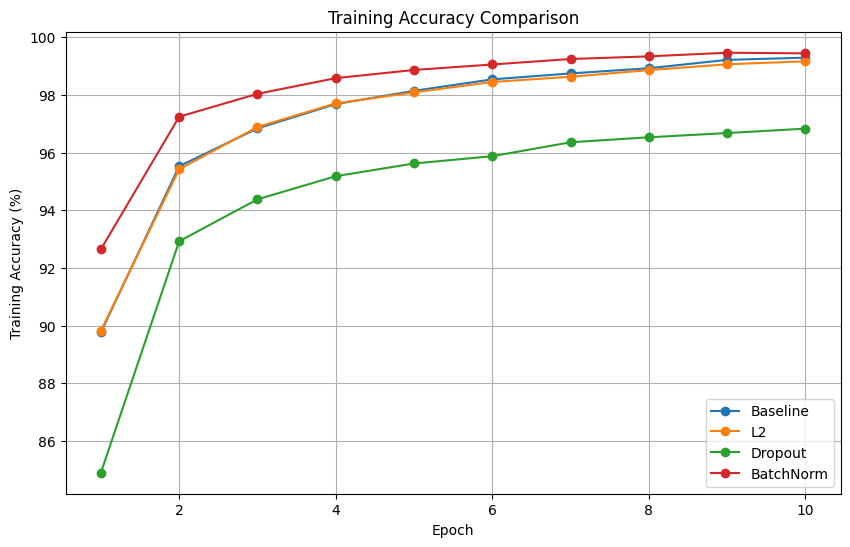

In [40]:
plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["train_acc"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()


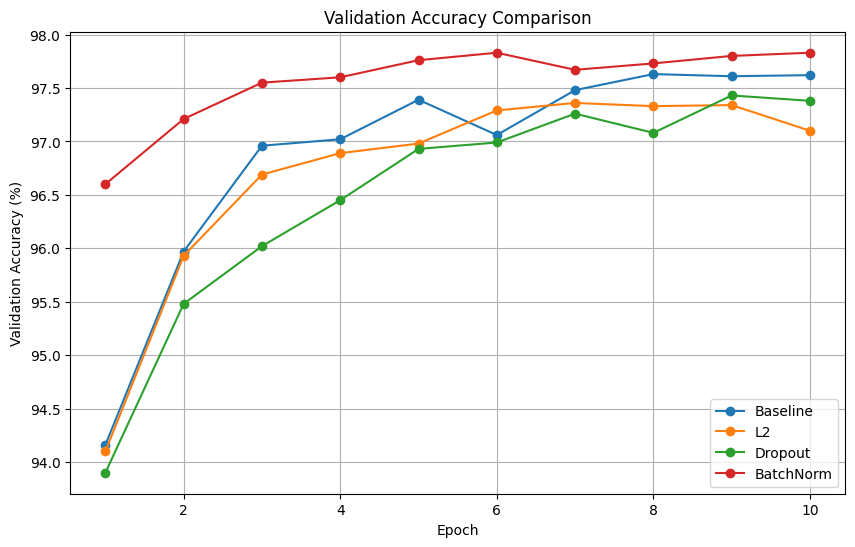

In [41]:
plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["val_acc"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

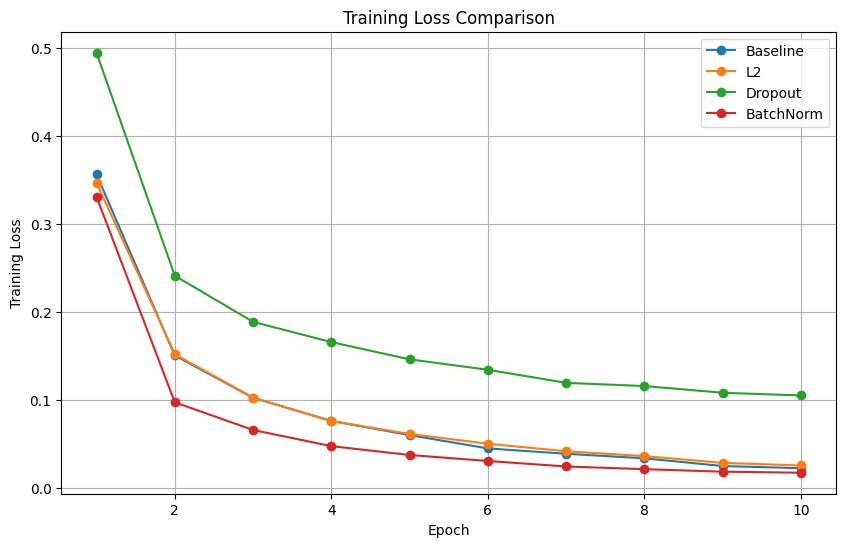

In [42]:
plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["train_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

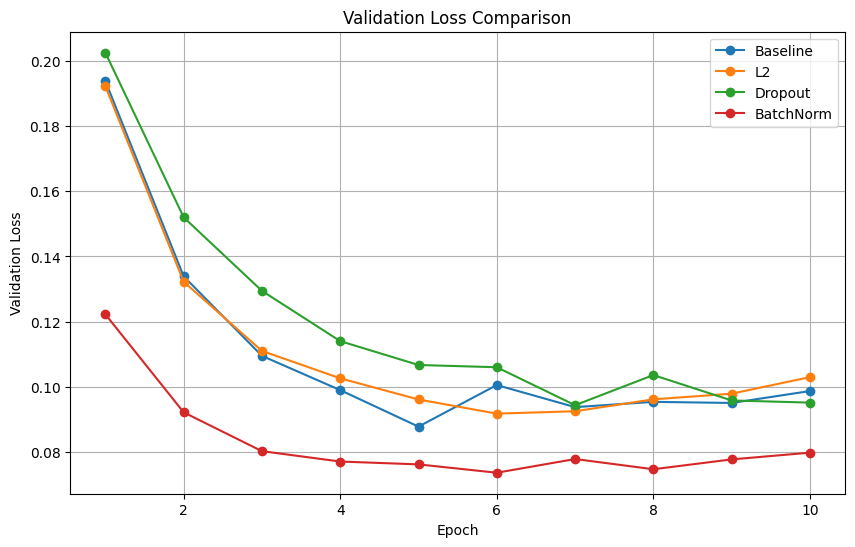

In [43]:
plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["val_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
print("\n")
print("=" * 70)
print("FINAL TEST ACCURACY")
print("=" * 70)

test_results = {}

for name, model in [

    ("Baseline", model_baseline),

    ("L2", model_l2),

    ("Dropout", model_dropout),

    ("BatchNorm", model_batchnorm)

]:

    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion
    )

    test_results[name] = test_accuracy

    print(
        f"{name:<15} "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Accuracy: {test_accuracy:.2f}%"
    )



FINAL TEST ACCURACY
Baseline        Test Loss: 0.0776 | Test Accuracy: 97.87%
L2              Test Loss: 0.0861 | Test Accuracy: 97.46%
Dropout         Test Loss: 0.0867 | Test Accuracy: 97.57%
BatchNorm       Test Loss: 0.0764 | Test Accuracy: 97.74%


In [45]:
print("\n")
print("=" * 85)
print("COMPLETE EXPERIMENT COMPARISON")
print("=" * 85)

print(
    f"{'Configuration':<15}"
    f"{'Train Acc.':<15}"
    f"{'Validation Acc.':<20}"
    f"{'Test Acc.':<15}"
)

print("-" * 65)

for name, history in results.items():

    train_acc = history["train_acc"][-1]

    val_acc = history["val_acc"][-1]

    test_acc = test_results[name]

    print(
        f"{name:<15}"
        f"{train_acc:<15.2f}"
        f"{val_acc:<20.2f}"
        f"{test_acc:<15.2f}"
    )



COMPLETE EXPERIMENT COMPARISON
Configuration  Train Acc.     Validation Acc.     Test Acc.      
-----------------------------------------------------------------
Baseline       99.29          97.62               97.87          
L2             99.17          97.10               97.46          
Dropout        96.83          97.38               97.57          
BatchNorm      99.44          97.83               97.74          


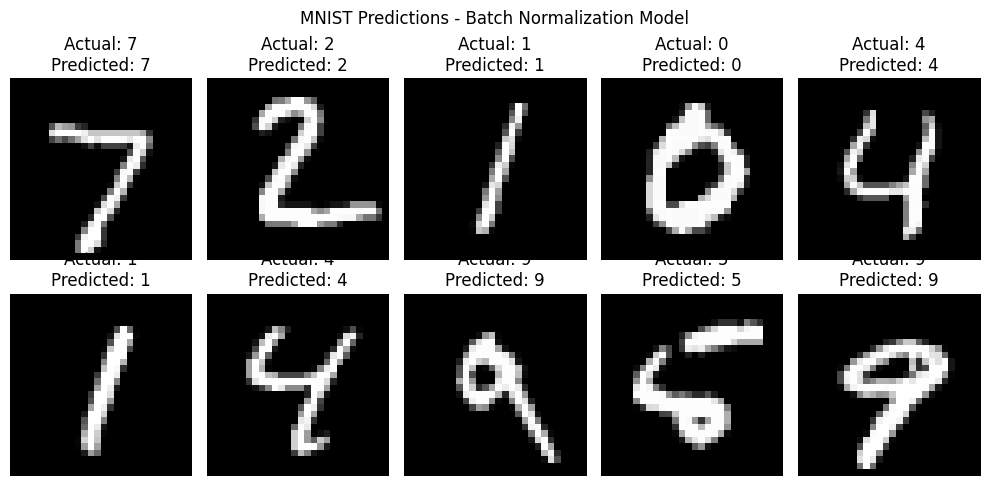

In [46]:
selected_model = model_batchnorm

selected_model.eval()


images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():

    outputs = selected_model(images_device)

    _, predictions = torch.max(outputs, 1)

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    actual = labels[i].item()

    predicted = predictions[i].item()

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")
plt.suptitle("MNIST Predictions - Batch Normalization Model")
plt.tight_layout()
plt.show()

In [47]:
print("\n")
print("=" * 70)
print("LAB 04 COMPLETED")
print("=" * 70)

print("""
Students have implemented and compared:

1. Baseline MLP
   -> No regularization

2. L2 Regularization
   -> Weight decay

3. Dropout
   -> Dropout p = 0.3

4. Batch Normalization
   -> BatchNorm1d

For every experiment we recorded:

    - Training Loss
    - Training Accuracy
    - Validation Loss
    - Validation Accuracy

We also evaluated all models on the unseen MNIST test dataset
and plotted their learning curves.
""")

print("=" * 70)



LAB 04 COMPLETED

Students have implemented and compared:

1. Baseline MLP
   -> No regularization

2. L2 Regularization
   -> Weight decay

3. Dropout
   -> Dropout p = 0.3

4. Batch Normalization
   -> BatchNorm1d

For every experiment we recorded:

    - Training Loss
    - Training Accuracy
    - Validation Loss
    - Validation Accuracy

We also evaluated all models on the unseen MNIST test dataset
and plotted their learning curves.

